# Realistic dataset 

In [15]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import glob
import os

In [16]:
# --- 1. Global Academic Style Configuration ---
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 13,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'lines.linewidth': 2,
    'lines.markersize': 6,
    'figure.dpi': 300,
    'savefig.bbox': 'tight',
})

In [17]:
plot_path = f"../results/Realistic_dataset"
os.makedirs(plot_path, exist_ok=True)

## Label error + ACC vs. alpha (d_MLP fix)

In [18]:
run_id_S = "20251217_1517"
run_id_tied = "20251217_0723"
run_id_untied = "20251216_1605"

run_dir_S = f"../results/run_{run_id_S}/"
config_path_S = f"../results/run_{run_id_S}/config.csv"
base_path_S = f"../results/run_{run_id_S}/summary.csv"

run_dir_tied = f"../results/run_{run_id_tied}/"
config_path_tied = f"../results/run_{run_id_tied}/config.csv"
base_path_tied = f"../results/run_{run_id_tied}/summary.csv"

run_dir_untied = f"../results/run_{run_id_untied}/"
config_path_untied = f"../results/run_{run_id_untied}/config.csv"
base_path_untied = f"../results/run_{run_id_untied}/summary.csv"

# --- Unfactorized ---
df_S = pd.read_csv(base_path_S)
print(f"✅ Summary loaded ({len(df_S)} rows) from {base_path_S}")
display(df_S.head())

# --- Tied ---
df_tied = pd.read_csv(base_path_tied)
print(f"✅ Summary loaded ({len(df_tied)} rows) from {base_path_tied}")
display(df_tied.head())

# --- Untied ---
df_untied = pd.read_csv(base_path_untied)
print(f"✅ Summary loaded ({len(df_untied)} rows) from {base_path_untied}")
display(df_untied.head())
plt.rcParams.update({'font.size': 12}) 

plt.rcParams.update({'font.size': 12}) 

✅ Summary loaded (15 rows) from ../results/run_20251217_0003/summary.csv


,alpha,MLP_dim,rho,p_ft,lamda,label_err_mean,label_err_std,train_data_mean,train_reg_mean,train_total_mean,...,acc_test_mean,acc_test_std,acc_fine_tune_mean,acc_fine_tune_std,acc_train_mean,acc_train_std,rank_before_mean,rank_before_std,rank_after_mean,rank_after_std
0,0.010000,100,1.0,0.0,0.0010,0.776542,0.014924,0.000089,0.000074,0.000162,...,0.223458,0.014924,NaN,NaN,0.718950,0.078186,97.2,3.293090,97.2,3.293090
1,0.151429,100,1.0,0.0,0.0001,0.522260,0.082992,0.000131,0.000021,0.000152,...,0.477740,0.082992,NaN,NaN,0.508436,0.114971,98.2,2.149935,98.2,2.149935
2,0.080714,100,1.0,0.0,0.0001,0.546642,0.096408,0.000123,0.000023,0.000146,...,0.453358,0.096408,NaN,NaN,0.545158,0.131417,98.2,1.751190,98.2,1.751190
3,0.222143,100,1.0,0.0,0.0001,0.497002,0.060641,0.000120,0.000021,0.000142,...,0.502998,0.060641,NaN,NaN,0.538707,0.073599,96.4,5.501515,96.4,5.501515
4,0.292857,100,1.0,0.0,0.0001,0.479283,0.082597,0.000120,0.000022,0.000141,...,0.520717,0.082597,NaN,NaN,0.550816,0.086601,96.8,2.658320,96.8,2.658320


✅ Summary loaded (15 rows) from ../results/run_20251217_0723/summary.csv


,alpha,MLP_dim,rho,p_ft,lamda,label_err_mean,label_err_std,train_data_mean,train_reg_mean,train_total_mean,...,acc_test_mean,acc_test_std,acc_fine_tune_mean,acc_fine_tune_std,acc_train_mean,acc_train_std,rank_before_mean,rank_before_std,rank_after_mean,rank_after_std
0,0.010000,100,1.0,0.0,0.00010,0.605285,0.009138,0.000008,0.000032,0.000040,...,0.394715,0.009138,NaN,NaN,0.983908,0.013707,98.6,1.349897,98.6,1.349897
1,0.151429,100,1.0,0.0,0.00001,0.143718,0.030573,0.000036,0.000013,0.000049,...,0.856282,0.030573,NaN,NaN,0.874512,0.017826,94.5,6.835366,94.5,6.835366
2,0.080714,100,1.0,0.0,0.00001,0.197515,0.067377,0.000038,0.000012,0.000050,...,0.802485,0.067377,NaN,NaN,0.848241,0.121434,93.3,9.202053,93.3,9.202053
3,0.363571,100,1.0,0.0,0.00001,0.143830,0.057495,0.000043,0.000013,0.000056,...,0.856170,0.057495,NaN,NaN,0.843735,0.091440,91.6,8.946756,91.6,8.946756
4,0.222143,100,1.0,0.0,0.00001,0.162127,0.090163,0.000042,0.000013,0.000054,...,0.837873,0.090163,NaN,NaN,0.847582,0.129814,92.2,9.028350,92.2,9.028350


✅ Summary loaded (15 rows) from ../results/run_20251216_1605/summary.csv


,alpha,MLP_dim,rho,p_ft,lamda,label_err_mean,label_err_std,train_data_mean,train_reg_mean,train_total_mean,...,acc_train_mean,acc_train_std,rank_Q_before_mean,rank_Q_before_std,rank_K_before_mean,rank_K_before_std,rank_Q_after_mean,rank_Q_after_std,rank_K_after_mean,rank_K_after_std
0,0.010000,100,1.0,0.0,0.0001,0.772847,0.019846,0.000030,0.000045,0.000075,...,0.864228,0.194309,97.0,3.651484,97.5,3.135815,97.0,3.651484,97.5,3.135815
1,0.151429,100,1.0,0.0,0.0001,0.321197,0.071804,0.000085,0.000041,0.000126,...,0.692813,0.080500,81.3,8.944893,81.4,8.617811,81.3,8.944893,81.4,8.617811
2,0.080714,100,1.0,0.0,0.0001,0.449703,0.058882,0.000083,0.000043,0.000126,...,0.691799,0.075520,86.3,6.600505,86.0,6.359595,86.3,6.600505,86.0,6.359595
3,0.222143,100,1.0,0.0,0.0001,0.326720,0.051927,0.000086,0.000040,0.000126,...,0.699904,0.058534,78.7,7.874713,77.4,8.834277,78.7,7.874713,77.4,8.834277
4,0.292857,100,1.0,0.0,0.0001,0.327175,0.081714,0.000091,0.000042,0.000133,...,0.683291,0.079766,81.6,7.691265,81.8,6.729702,81.6,7.691265,81.8,6.729702


✅ Saved plot: ../results/Realistic_dataset/label_error_vs_alpha_MLP100_run20251217_0003.png


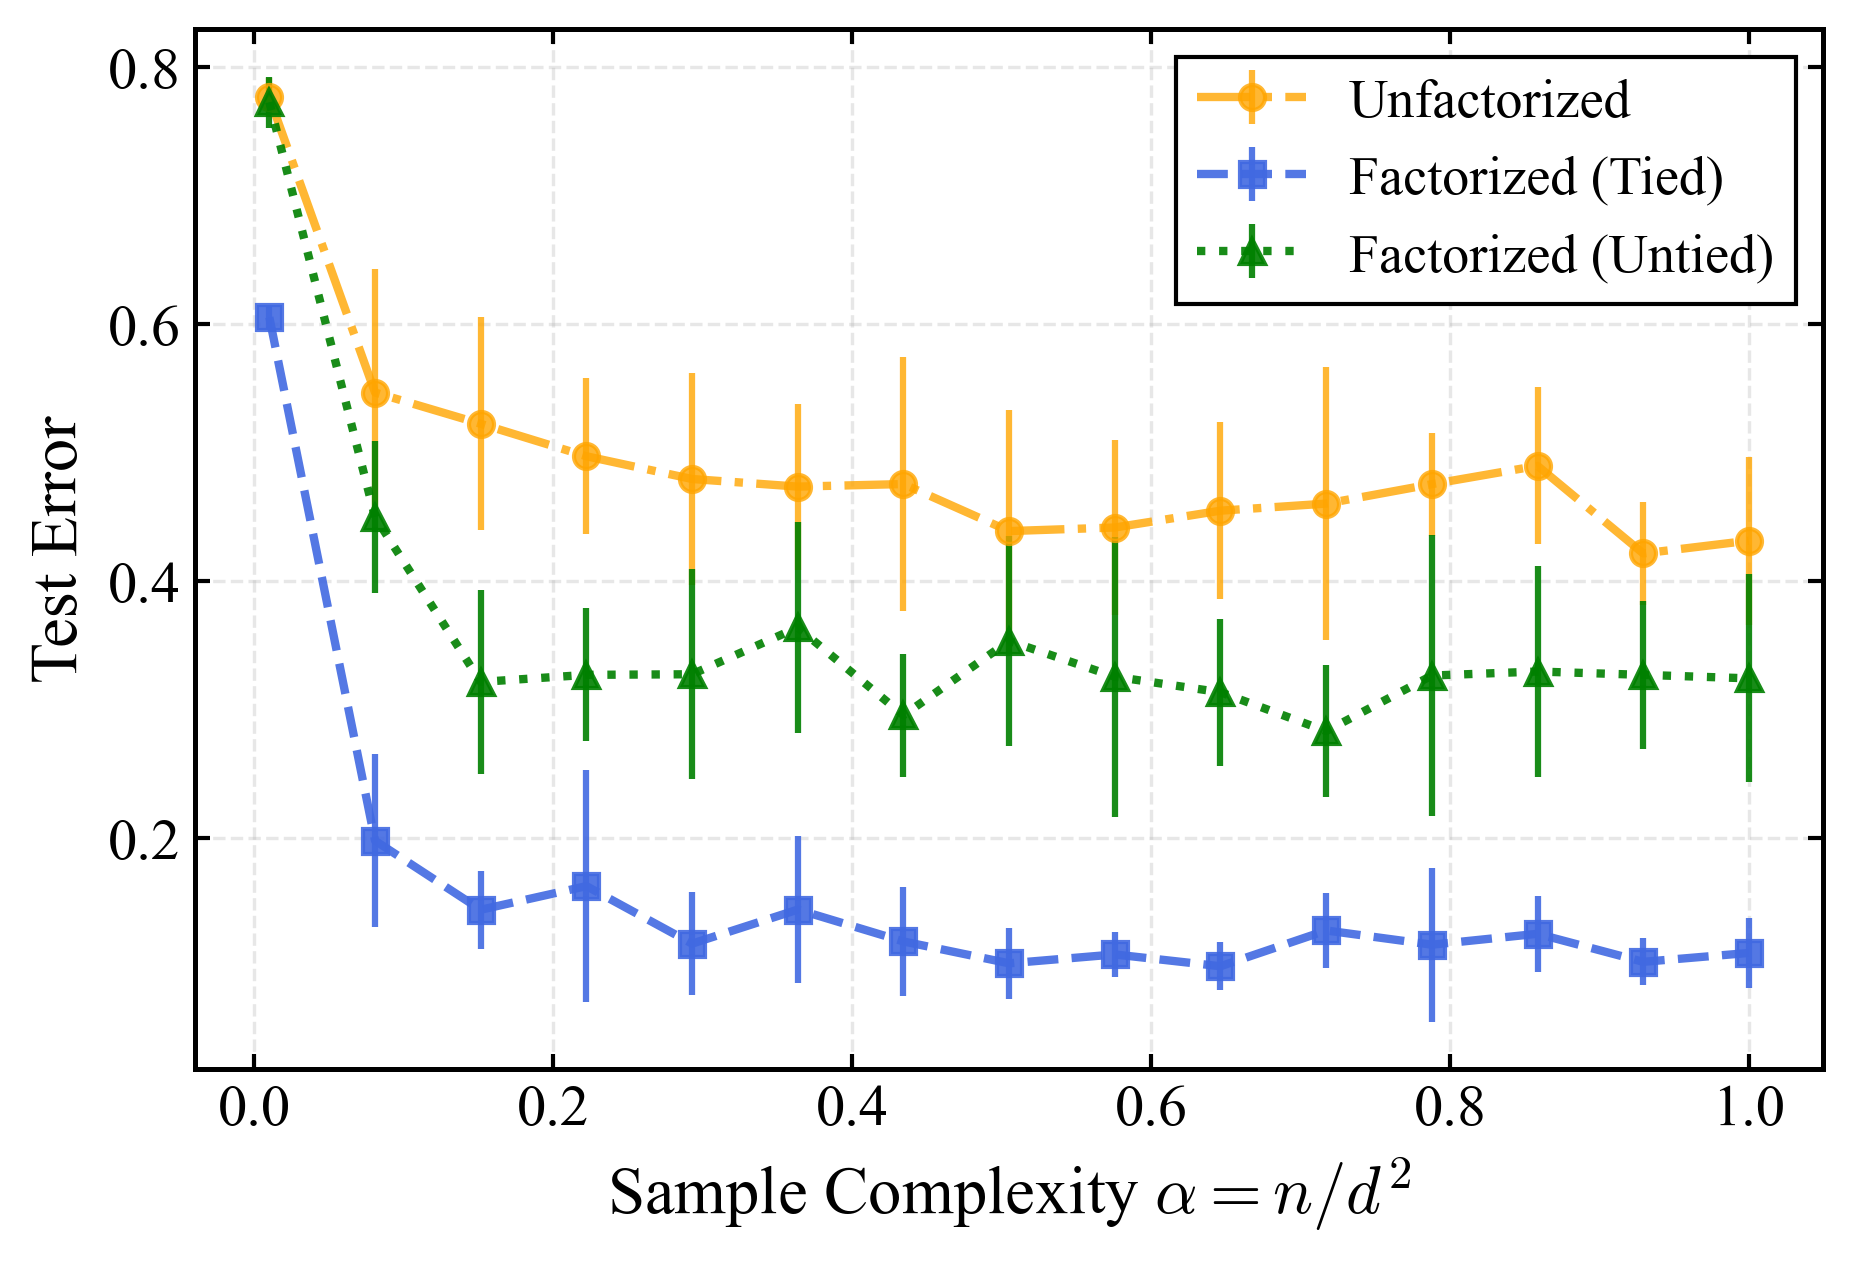

✅ Saved plot: ../results/Realistic_dataset/test_accuracy_vs_alpha_MLP100_run20251217_0003.png


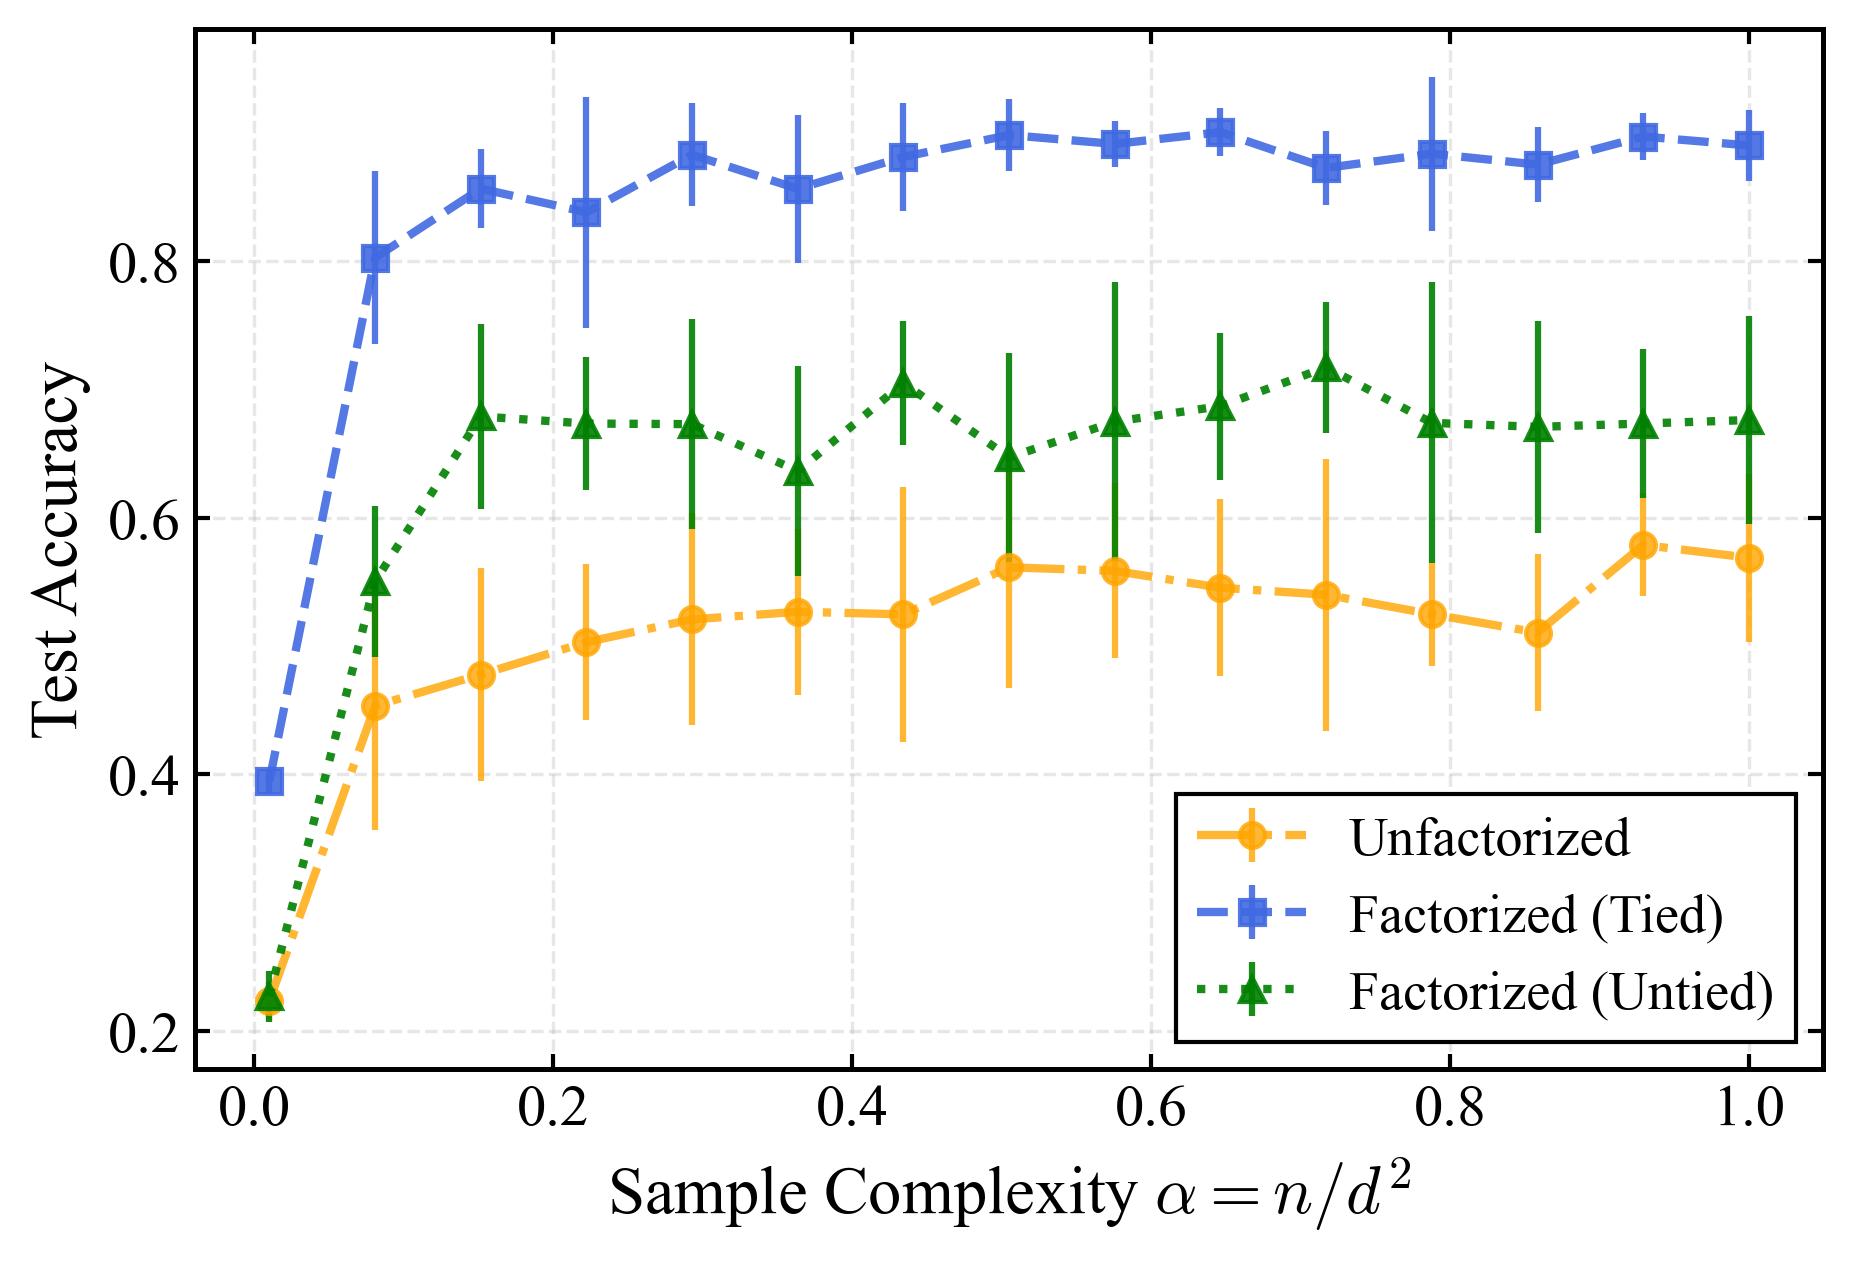

In [19]:
# --- 2. Préparation des données ---
MLP_target = 100  # <-- Choisis ton d_MLP

# Vérification et filtrage pour les 3 DataFrames
if 'df_S' in locals() and 'df_tied' in locals() and 'df_untied' in locals():
    subset_S = df_S[df_S["MLP_dim"] == MLP_target].sort_values("alpha")
    subset_tied = df_tied[df_tied["MLP_dim"] == MLP_target].sort_values("alpha")
    subset_untied = df_untied[df_untied["MLP_dim"] == MLP_target].sort_values("alpha")
else:
    print("⚠️ DataFrames 'df_S', 'df_tied' or 'df_untied' not found.")
    subset_S, subset_tied, subset_untied = pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

# --- 3. Fonction de Plot Générique ---
def plot_compare_vs_alpha(
    data_s, data_tied, data_untied, # <--- Ajout de data_untied
    y_col, y_err_col, 
    ylabel, filename, 
    loc_legend='best'
):
    fig, ax = plt.subplots(figsize=(7, 4.5))

    # --- Courbe 1 : Unfactorized (Référence - Orange) ---
    ax.errorbar(
        data_s["alpha"],
        data_s[y_col],
        yerr=data_s.get(y_err_col, 0),
        label="Unfactorized",
        color='orange',
        marker='o',
        linestyle='-.',
        capsize=0,
        elinewidth=1.5,
        alpha=0.8
    )

    # --- Courbe 2 : Factorized (Tied - RoyalBlue) ---
    ax.errorbar(
        data_tied["alpha"],
        data_tied[y_col],
        yerr=data_tied.get(y_err_col, 0),
        label="Factorized (Tied)",
        color='royalblue',
        marker='s',
        linestyle='--',
        capsize=0,
        elinewidth=1.5,
        alpha=0.9
    )

    # --- Courbe 3 : Factorized (Untied - Green) ---
    ax.errorbar(
        data_untied["alpha"],
        data_untied[y_col],
        yerr=data_untied.get(y_err_col, 0),
        label="Factorized (Untied)",
        color='green',      # Vert
        marker='^',         # Triangle
        linestyle=':',      # Pointillés
        capsize=0,
        elinewidth=1.5,
        alpha=0.9
    )

    # --- Labels et Style ---
    ax.set_xlabel(r"Sample Complexity $\alpha = n/d^2$")
    ax.set_ylabel(ylabel)

    # --- STYLE BOÎTE (Box Style) ---
    ax.set_axisbelow(True)
    ax.tick_params(direction='in', top=True, right=True, which='both', width=1.0)
    
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.2)

    # Légende
    ax.legend(frameon=True, fancybox=False, edgecolor='black', framealpha=1.0, loc=loc_legend)
    
    save_full = os.path.join(plot_path, filename)
    plt.savefig(save_full, dpi=300, bbox_inches='tight')
    print(f"✅ Saved plot: {save_full}")
    plt.show()

# --- 4. Exécution ---

if not subset_S.empty and not subset_tied.empty and not subset_untied.empty:
    
    # Récupération d'un ID de run pour le nom de fichier (optionnel)
    run_suffix = f"_run{run_id_S}" if 'run_id_S' in locals() else ""

    # -------------------- LABEL ERROR --------------------
    plot_compare_vs_alpha(
        subset_S, subset_tied, subset_untied, # <--- 3 arguments
        y_col="label_err_mean",
        y_err_col="label_err_std",
        ylabel="Test Error",
        filename=f"label_error_vs_alpha_MLP{MLP_target}{run_suffix}.png",
        loc_legend="upper right" 
    )

    # -------------------- TEST ACCURACY --------------------
    plot_compare_vs_alpha(
        subset_S, subset_tied, subset_untied, # <--- 3 arguments
        y_col="acc_test_mean",
        y_err_col="acc_test_std",
        ylabel="Test Accuracy",
        filename=f"test_accuracy_vs_alpha_MLP{MLP_target}{run_suffix}.png",
        loc_legend="lower right"
    )

else:
    print(f"⚠️ One of the subsets is empty for MLP_dim = {MLP_target}")